In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

#Upload the dataset
print("Please upload your homeloan4.csv file:")
uploaded = files.upload()

#Load the dataset into a Pandas DataFrame
df = pd.read_csv('homeloan4.csv')
print("\nData loaded successfully!")

Please upload your homeloan4.csv file:


Saving homeloan4.csv to homeloan4 (1).csv

Data loaded successfully!


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            592 non-null    object 
 1   Gender             579 non-null    object 
 2   Married            590 non-null    object 
 3   Dependents         579 non-null    object 
 4   Education          592 non-null    object 
 5   Self_Employed      561 non-null    object 
 6   ApplicantIncome    592 non-null    int64  
 7   CoapplicantIncome  592 non-null    float64
 8   LoanAmount         592 non-null    int64  
 9   Loan_Amount_Term   578 non-null    float64
 10  Credit_Score       543 non-null    float64
 11  Property_Area      592 non-null    object 
 12  Loan_Status        592 non-null    object 
dtypes: float64(3), int64(2), object(8)
memory usage: 60.3+ KB

--- Summary Statistics ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_Score,Property_Area,Loan_Status
count,592,579,590,579,592,561,592.000000,592.000000,592.000000,578.000000,543.000000,592,592
unique,592,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002941,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,B,Y
freq,1,470,384,334,465,482,NaN,NaN,NaN,NaN,NaN,228,412
mean,NaN,NaN,NaN,NaN,NaN,NaN,5404.304054,1642.633311,146.412162,342.145329,0.843462,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6164.073003,2967.717486,85.587325,65.442101,0.363699,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2887.250000,0.000000,100.000000,360.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3806.000000,1221.000000,128.000000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5754.500000,2312.000000,168.000000,360.000000,1.000000,NaN,NaN



--- Missing Values Check ---
Loan_ID               0
Gender               13
Married               2
Dependents           13
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_Score         49
Property_Area         0
Loan_Status           0
dtype: int64


/tmp/ipykernel_591/1876435996.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='viridis')


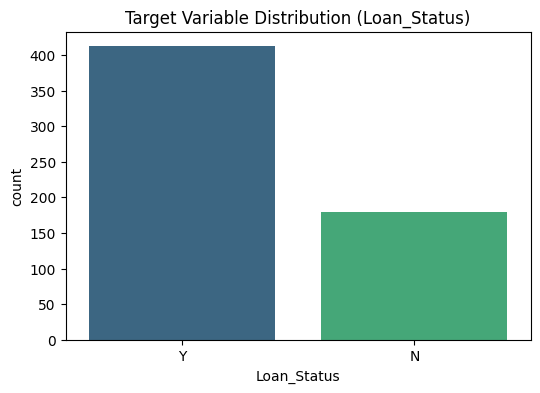

In [6]:
# Display basic info and missing values
print("--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Visualize distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='viridis')
plt.title('Target Variable Distribution (Loan_Status)')
plt.show()

In [7]:
df_clean = df.copy()

#Eliminate Loan_ID as it provides no value to this analysis
df_clean.drop('Loan_ID', axis=1, inplace=True, errors='ignore')

# Impute missing numeric/ordinal values with median
for col in ['Loan_Amount_Term', 'Credit_Score']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Categorical values to be impute with mode
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("Missing Values After Cleaning")
print(df_clean.isnull().sum())

# Convert text to numbers
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Separate features (X) and target (y)
X = df_clean.drop('Loan_Status', axis=1)
y = df_clean['Loan_Status'] # 1 = Y (Approved), 0 = N (Rejected)

# Train/Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("\nData cleaned, encoded, and split successfully!")

Missing Values After Cleaning
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_Score         0
Property_Area        0
Loan_Status          0
dtype: int64

Data cleaned, encoded, and split successfully!


/tmp/ipykernel_591/2016934137.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_591/2016934137.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

================ CART MODEL ================
CART Size (Number of leaves): 12
CART Test Accuracy: 0.8315



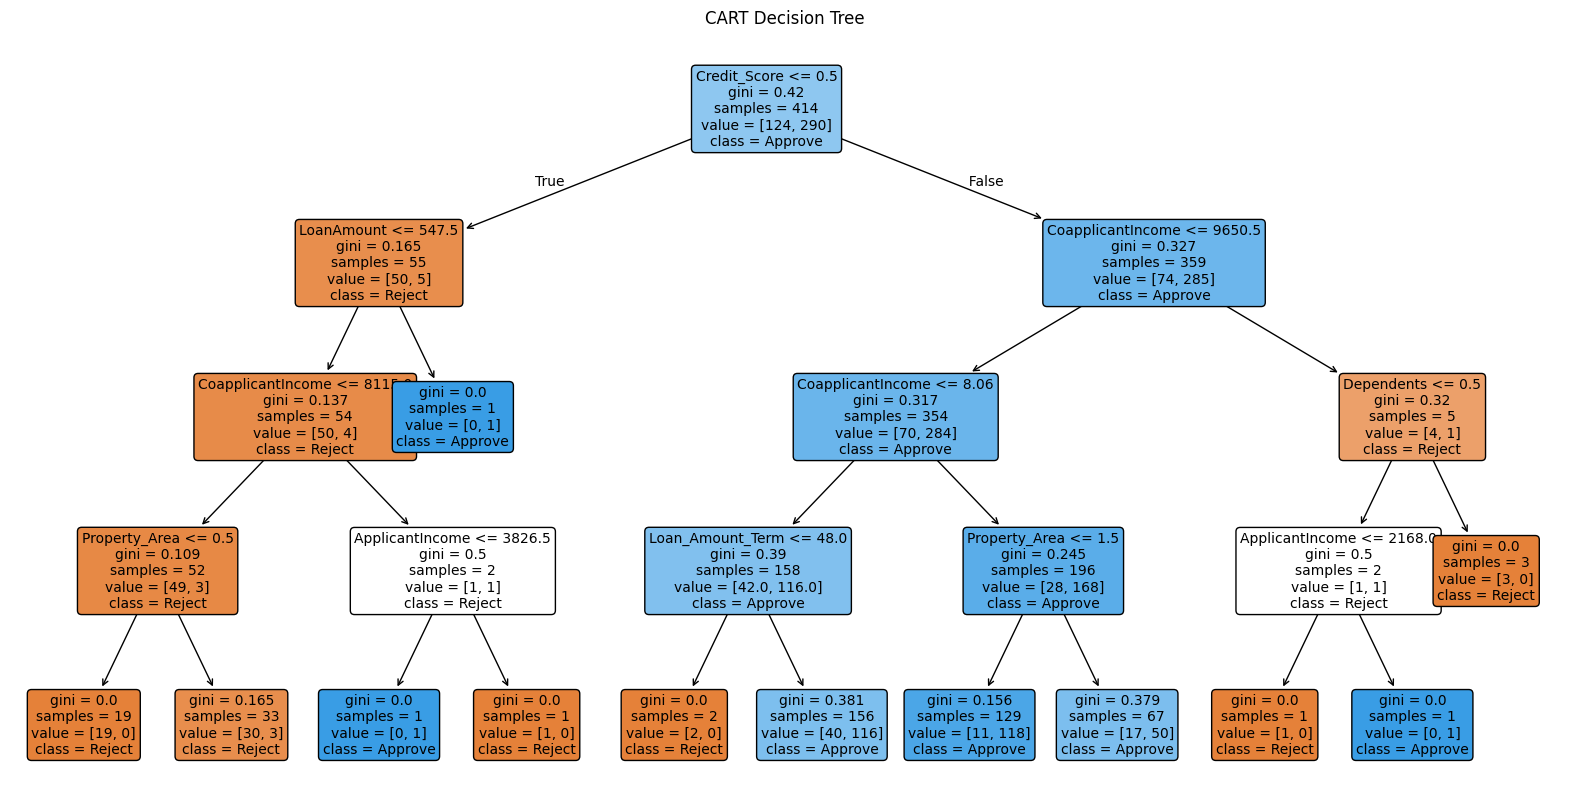

LOGISTIC REGRESSION MODEL
Logistic Regression Size (Number of Coefficients): 11
Logistic Regression Test Accuracy: 0.8315

Logistic Regression Coefficients:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Feature,Coefficient
9,Credit_Score,3.073404
1,Married,0.375433
0,Gender,0.171037
2,Dependents,0.095582
5,ApplicantIncome,-0.000001
6,CoapplicantIncome,-0.000061
7,LoanAmount,-0.000975
8,Loan_Amount_Term,-0.002122
4,Self_Employed,-0.045053
10,Property_Area,-0.084803


In [8]:
# CART MODEL
# Train the model (maximum depth will be 4 to prevent overfitting)
cart_model = DecisionTreeClassifier(max_depth=4, random_state=42)
cart_model.fit(X_train, y_train)

# Evaluate
cart_pred = cart_model.predict(X_test)
cart_acc = accuracy_score(y_test, cart_pred)
cart_size = cart_model.get_n_leaves()

print("================ CART MODEL ================")
print(f"CART Size (Number of leaves): {cart_size}")
print(f"CART Test Accuracy: {cart_acc:.4f}\n")

# Plot Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(cart_model, feature_names=X.columns, class_names=['Reject', 'Approve'], filled=True, rounded=True, fontsize=10)
plt.title("CART Decision Tree")
plt.show()



# LOGISTIC REGRESSION MODEL
# Train the model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Evaluate
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)
log_size = len(log_model.coef_[0]) # Number of coefficients

print("LOGISTIC REGRESSION MODEL")
print(f"Logistic Regression Size (Number of Coefficients): {log_size}")
print(f"Logistic Regression Test Accuracy: {log_acc:.4f}\n")

# Display the coefficients clearly
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
display(coef_df)